In [ ]:
# Setup - Import Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Must run before ANYTHING else touches the GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)     # Allows TensorFlow to allocate GPU memory as needed instead of pre-allocating all memory at once
    print(f"GPU ready: {gpus[0].name}")

print(f"TensorFlow version: {tf.__version__}")
np.random.seed(42)
tf.random.set_seed(42)

# Constants
LATENT_DIM = 8
KL_WEIGHT = 10.0
BATCH_SIZE = 128

2026-03-09 18:56:22.233364: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 18:56:22.289427: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 18:56:23.461981: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU ready: /physical_device:GPU:0
TensorFlow version: 2.20.0


In [2]:
# Create Custom Sampling Layer with reparameterization
class Sampling(layers.Layer):
    '''
    Samples from the distribution using reparameterization
    z = mu + sigma * epsilon, where epsilon ~ N(0, 1)
    '''
    def call(self, inputs):
        z_mean, z_log_var = inputs

        # Sample epsilon from standard normal (random noise)
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean))

        # Return z = mu + sigma * epsilon
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

In [3]:
# Build the Encoder
def build_encoder(input_shape=(32, 32, 1), latent_dim=LATENT_DIM):      # 1 channel for grayscale MNIST
    '''
    Encoder: Input -> Conv layers -> Mean & Log Variance
    '''
    inputs = keras.Input(shape=input_shape)

    # Convolutional layers (strides=2 for downsampling)
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Flatten to vector
    x = layers.Flatten()(x)

    # Output: Mean and Log Variance (not single encoding)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)     # center of distribution
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)   # spread of distribution

    # Sample a point from distribution
    z = Sampling()([z_mean, z_log_var])
    
    return keras.Model(inputs, [z_mean, z_log_var, z], name='encoder')

In [4]:
# Build the Decoder
def build_decoder(latent_dim=LATENT_DIM, output_shape=(32, 32, 1)):
    '''
    Decoder: Latent vector -> Upsample -> Output image
    '''
    latent_inputs = keras.Input(shape=(latent_dim,))
   
    # Dense layer to start spatial dimensions
    x = layers.Dense(4 * 4 * 128, activation='relu')(latent_inputs)
    x = layers.Reshape((4, 4, 128))(x)
  
    # Transposed convolutions to upsample
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
   
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
  
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
   
    # Final convolution to get gray-scale output (1 channel as using MNIST dataset) with sigmoid activation
    outputs = layers.Conv2D(1, 3, padding='same', activation='sigmoid')(x)

    return keras.Model(latent_inputs, outputs, name='decoder')

In [ ]:
# Combine Encoder and Decoder into VAE

class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight=KL_WEIGHT, **kwargs):
        super().__init__(**kwargs)
        # Store encoder, decoder and kl_weight as parts of the model
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = tf.Variable(float(kl_weight), trainable=False)

    def call(self, x):
        # Forward pass: encode input, decode the sampled point
        z_mean, z_log_var, z = self.encoder(x)
        return self.decoder(z)

    def _compute_losses(self, x, reconstruction, z_mean, z_log_var):
        image_size = tf.cast(tf.reduce_prod(tf.shape(x)[1:3]), tf.float32)
        
        # Evaluate how well input reconstructed
        recon_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstruction)     # Binary cross-entropy loss for pixel-wise comparison and as MNIST is grayscale and sigmoid output is used
        ) *image_size
        
        # Evaluates how organised latent space is (penalises deviation from standard normal)
        kl_loss = -0.5 * tf.reduce_mean(
            z_log_var - tf.square(z_mean) - tf.exp(z_log_var) + 1
        )
        total_loss = recon_loss + self.kl_weight * kl_loss
        return {"loss": total_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

    def train_step(self, data):
        x, _ = data     # x is both input and target (autoencoder)
        with tf.GradientTape() as tape:
            
            # Encode: get distribution parameters and a sampled point
            z_mean, z_log_var, z = self.encoder(x, training=True)
            
            # Decode: reconstruct the input from the sampled point
            reconstruction = self.decoder(z, training=True)
            losses = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        
        grads = tape.gradient(losses["loss"], self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return losses

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        reconstruction = self.decoder(z, training=False)
        return self._compute_losses(x, reconstruction, z_mean, z_log_var)

encoder = build_encoder(latent_dim=LATENT_DIM)
decoder = build_decoder(latent_dim=LATENT_DIM)
vae = VAE(encoder, decoder, kl_weight=KL_WEIGHT, name='vae')      # higher kl_weight better generations but worse reconstructions
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))
print("VAE built successfully")

I0000 00:00:1773082584.418013   83806 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


VAE built successfully


In [6]:
# Load MNIST data for training
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalise to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Pad from 28x28 to 32x32
x_train = np.pad(x_train, ((0,0), (2,2), (2,2)), mode='constant')
x_test = np.pad(x_test, ((0,0), (2,2), (2,2)), mode='constant')

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

print(f"Training data: {x_train.shape}")
print(f"Test data: {x_test.shape}")

Training data: (60000, 32, 32, 1)
Test data: (10000, 32, 32, 1)


In [ ]:
# Train

# Optimisation
# Prefetching so that GPU is never bottlenecked and idle waiting for the CPU
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, x_train))
train_dataset = train_dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((x_test, x_test))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Optionally can include callbacks for early stopping and reducing learning rate on plateau
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
)

history = vae.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/50


2026-03-09 18:56:30.167694: I external/local_xla/xla/service/service.cc:163] XLA service 0x77140c002b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-09 18:56:30.167750: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-09 18:56:30.248440: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-09 18:56:30.836043: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


 19/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 2.2111 - loss: 657.5467 - recon_loss: 635.4356 

I0000 00:00:1773082596.638878   83893 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - kl_loss: 1.8999 - loss: 124.3763 - recon_loss: 105.3776 - val_kl_loss: 1.5569 - val_loss: 321.9613 - val_recon_loss: 306.3923 - learning_rate: 0.0010
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 1.8762 - loss: 126.7480 - recon_loss: 107.9858 - val_kl_loss: 2.0170 - val_loss: 118.6291 - val_recon_loss: 98.4587 - learning_rate: 0.0010
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 1.9951 - loss: 114.9379 - recon_loss: 94.9870 - val_kl_loss: 2.0590 - val_loss: 114.9192 - val_recon_loss: 94.3288 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 1.9388 - loss: 115.4990 - recon_loss: 96.1113 - val_kl_loss: 1.9504 - val_loss: 115.7271 - val_recon_loss: 96.2229 - learning_rate: 0.0010
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 1.9478 - loss: 111.4914 - recon_loss: 92.0132 - val_kl_loss: 1.9058 - val_loss: 108.0999 - val_recon_loss: 89.0420 - learning_rate: 0.0

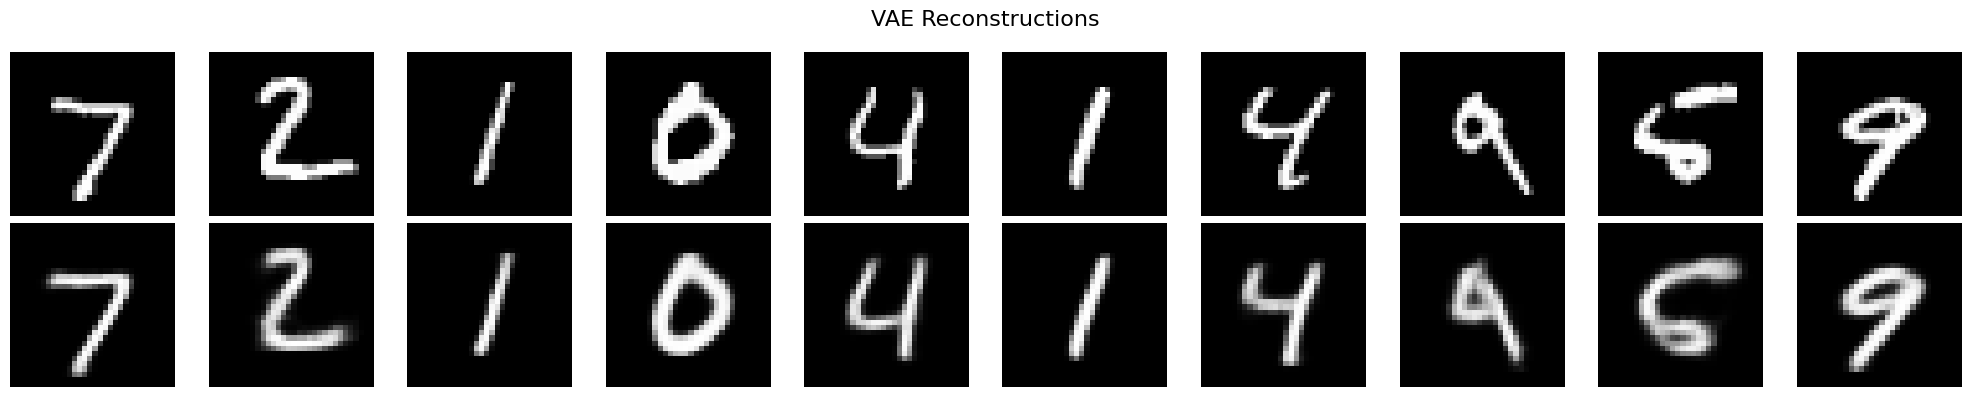

In [8]:
# Reconstructing Image

# Test reconstructions
test_samples = x_test[:10]
reconstructed = vae.predict(test_samples, verbose=0)

# Visualize
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    # Original
    axes[0, i].imshow(test_samples[i], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=12)

    # Reconstructed
    axes[1, i].imshow(np.clip(reconstructed[i], 0, 1), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Reconstructed', fontsize=12)

plt.suptitle('VAE Reconstructions', fontsize=16)
plt.tight_layout()
plt.show()

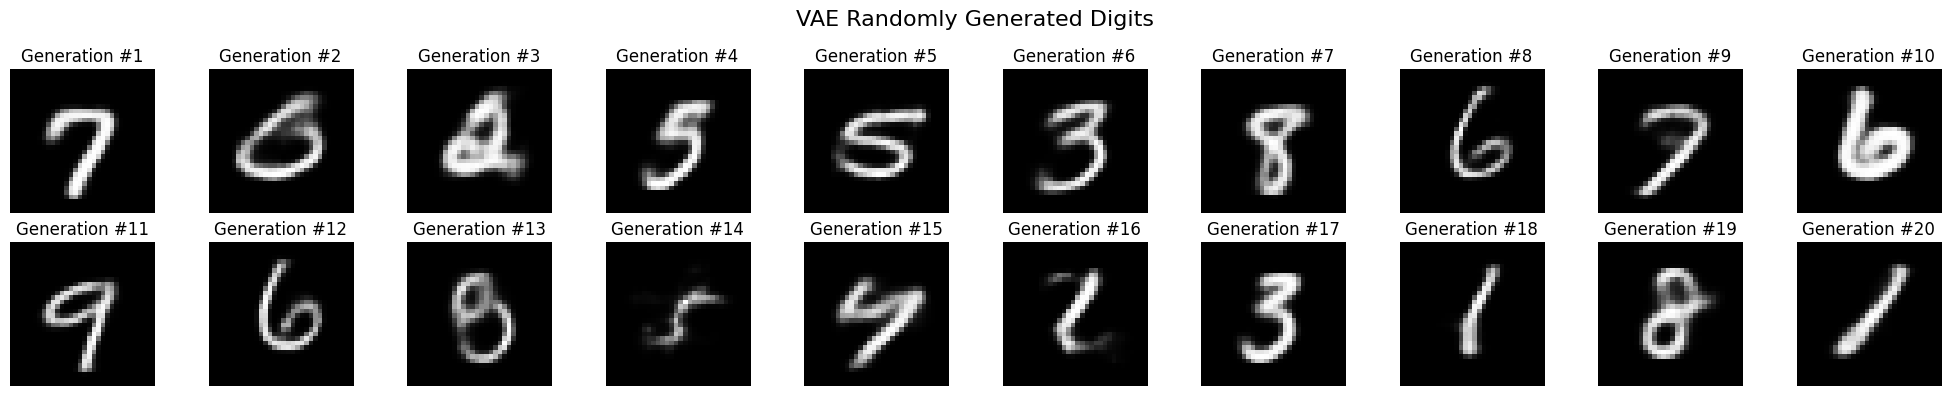

In [9]:
# Generate New Images

# Sample random latent vectors from standard normal
n_samples = 20
random_latent = np.random.normal(size=(n_samples, LATENT_DIM))

# Decode to images
generated = decoder.predict(random_latent, verbose=0)

# Visualize

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.clip(generated[i], 0, 1), cmap='gray')
    ax.set_title(f'Generation #{i+1}')
    ax.axis('off')

plt.suptitle('VAE Randomly Generated Digits', fontsize=16)
plt.tight_layout()
plt.show()

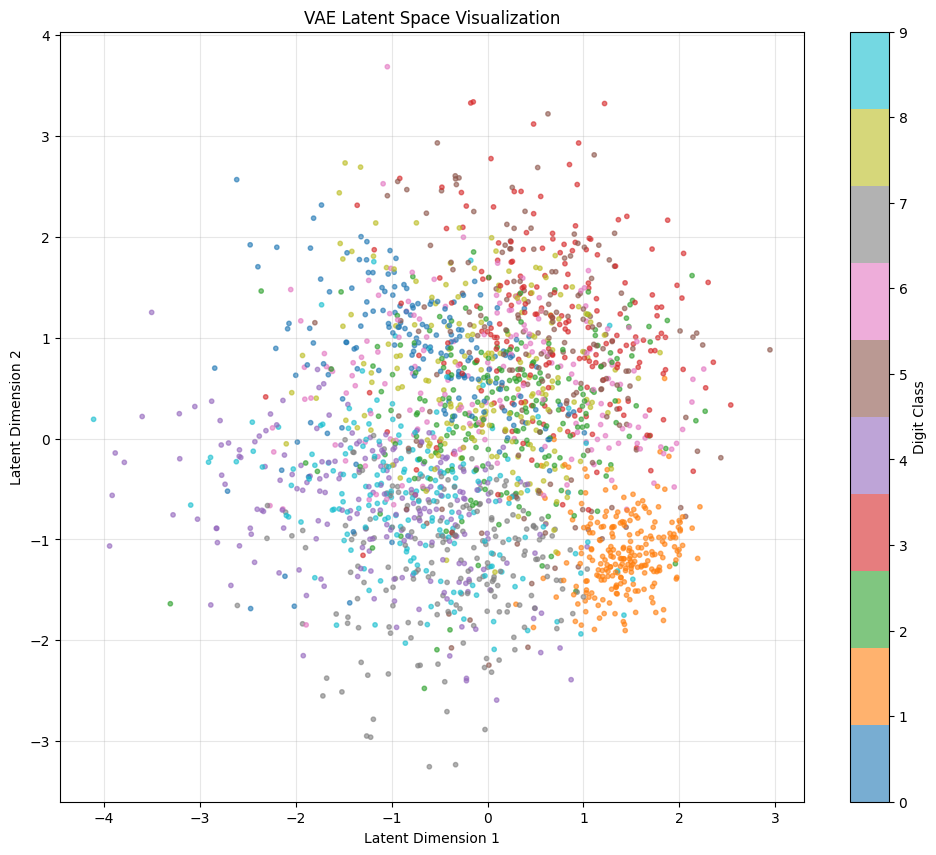

In [10]:
# Visualise Latent Space

# Encode test images
from encodings.punycode import digits

z_mean, _, _ = encoder.predict(x_test[:2000], verbose=0)

# Reduce to 2D for visualization
if z_mean.shape[1] > 2:
    # Centre the data
    z_centered = z_mean - np.mean(z_mean, axis=0)
    # Compute covariance matrix
    cov = np.cov(z_centered.T)
    # Get eigenvectors and eigenvalues
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Sort by largest eigenvalues and take top 2
    top2 = eigenvectors[:, np.argsort(eigenvalues)[::-1][:2]]
    # Project down to 2D
    z_2d = z_centered @ top2
else:
    z_2d = z_mean

# Plot with digit labels as colors
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    z_2d[:, 0], z_2d[:, 1],
    c=y_test[:2000],
    cmap='tab10',
    alpha=0.6,
    s=10
)

plt.colorbar(scatter, label='Digit Class')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('VAE Latent Space Visualization')     # Digits of the same class cluster together
plt.grid(True, alpha=0.3)
plt.show()

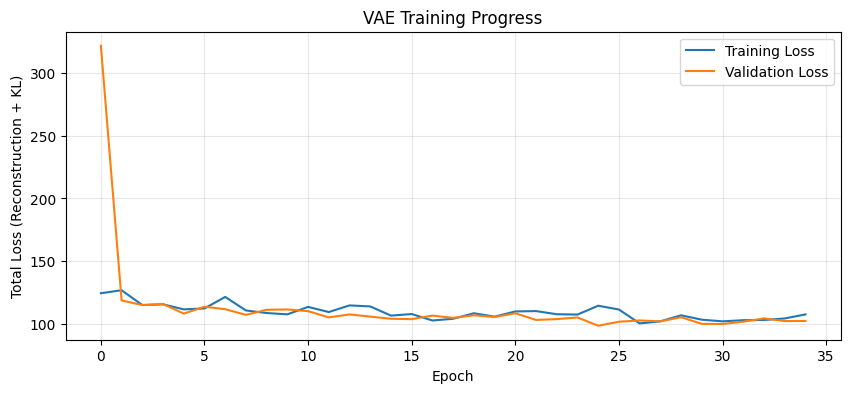

In [11]:
# Training History

# Plot loss over time
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Total Loss (Reconstruction + KL)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('VAE Training Progress')
plt.show()